In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import lightgbm as lgb
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


# 1. Data Loading 

In [2]:
data_path = 'data/'
try:
    train_df = pd.read_csv(data_path + 'train.csv')
    test_df = pd.read_csv(data_path + 'test.csv')
    sample_submission_df = pd.read_csv(data_path + 'sample_submission.csv')
except FileNotFoundError as e:
    train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
    test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
    sample_submission_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv')

print("Train data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

Train data shape: (630000, 21)
Test data shape: (270000, 20)


# 2. Data Cleaning & Quality Check

In this section, we perform a basic data quality check by identifying missing values, duplicates, and examining the distribution of features to ensure there are no unexpected outliers or data entry errors.

In [3]:
print(f"Total missing values: {train_df.isnull().sum().sum()}")
print(f"Total duplicate rows: {train_df.duplicated().sum()}")
train_df.describe()

Total missing values: 0
Total duplicate rows: 0


,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


# 3. Feature Engineering

Feature engineering is a critical step in building robust machine learning models. In this section, we implement advanced techniques to extract maximum signal from the data while avoiding redundant or collinear features:

1. **Frequency Encoding**: We encode categorical variables (`Crop_Type`, `Soil_Type`, `Region`, `Season`) by their frequency. This helps the model identify common vs. rare environmental configurations which often correlate with standard irrigation practices.
2. **Ordinal Target Encoding**: We map the target `Irrigation_Need` to numerical values (Low=0, Medium=1, High=2) and calculate the mean for each crop and soil type. This provides a direct supervised signal that quantifies the 'thirst' of different crops.
3. **Quantile Binning**: Continuous variables like `Rainfall_mm` are discretized into 10 bins. This allows the tree-based model to capture non-linear 'step' effects in water requirements more easily.
4. **Non-linear Proxies**: We create interaction features like `Water_Stress_Index` (Evapotranspiration proxy) and `Rain_Moisture_Ratio` to capture complex physiological relationships that a model might miss with raw features alone.

In [4]:
def create_features(train, test):
    # Combine for global frequency stats
    df_all = pd.concat([train, test], axis=0).reset_index(drop=True)
    
    # 1. Frequency Encoding
    for col in ['Crop_Type', 'Soil_Type', 'Region', 'Season']:
        freq_map = df_all[col].value_counts().to_dict()
        train[f'{col}_Freq'] = train[col].map(freq_map)
        test[f'{col}_Freq'] = test[col].map(freq_map)

    # 2. Binning Top Features
    train['Sunlight_Bin'] = pd.qcut(train['Sunlight_Hours'], 5, labels=False)
    test['Sunlight_Bin'] = pd.qcut(test['Sunlight_Hours'], 5, labels=False)

    # 3. High-impact Non-linear proxies
    for df in [train, test]:
        df['Water_Stress_Index'] = (df['Temperature_C'] * df['Wind_Speed_kmh']) / (df['Humidity'] + 1)
        df['Rain_Moisture_Ratio'] = df['Rainfall_mm'] / (df['Soil_Moisture'] + 1)
        df['Evap_Potential'] = (df['Temperature_C'] * (100 - df['Humidity'])) / 100
        df['Temp_Sun_Ratio'] = df['Temperature_C'] / (df['Sunlight_Hours'] + 1)
        
    # Removed target encoding from here to fix leakage (moved to CV loop)
    return train, test

train_df, test_df = create_features(train_df, test_df)
print("Advanced features added. Shape:", train_df.shape)

Advanced features added. Shape: (630000, 30)


### 3.1 Feature Correlation Analysis

To ensure our new features are not redundant or adding noise, we'll examine their correlation with the target and their base components. High correlation between features (multicollinearity) can sometimes negatively impact model performance.

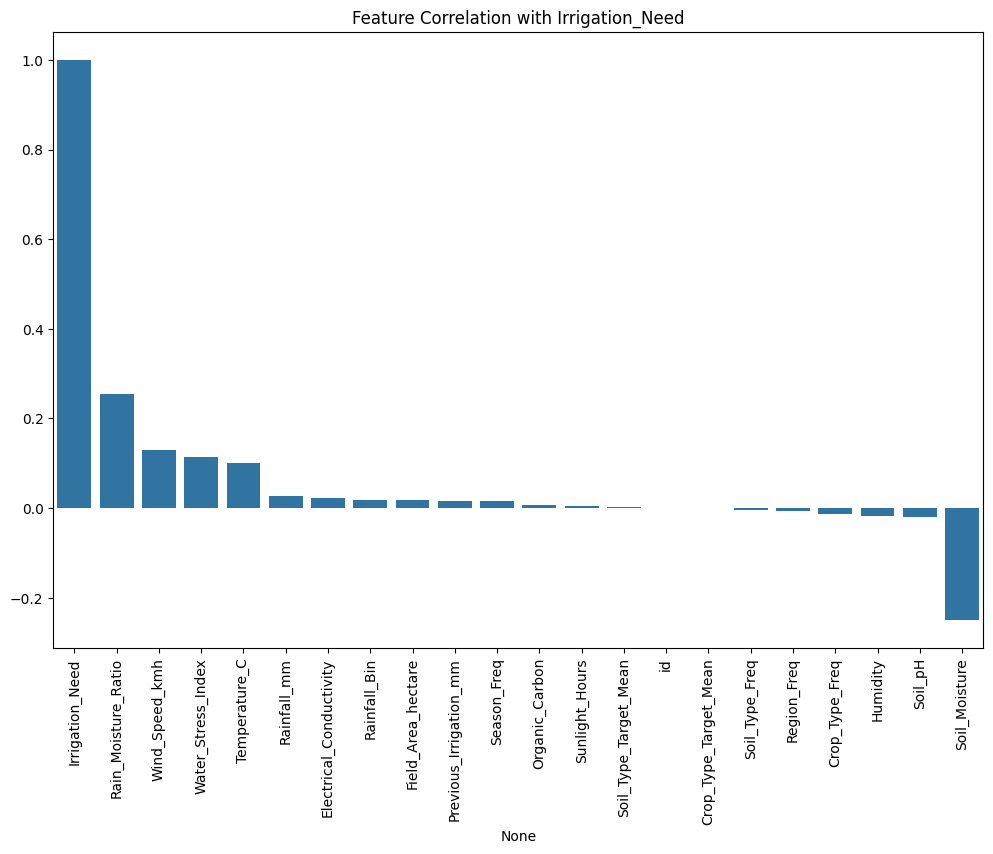

Features with > 0.9 correlation with another feature:
['Rainfall_Bin']


In [5]:
def analyze_correlation(df, target_col):
    temp_df = df.copy()
    le = LabelEncoder()
    if temp_df[target_col].dtype == 'object':
        temp_df[target_col] = le.fit_transform(temp_df[target_col])
    corr_matrix = temp_df.select_dtypes(include=[np.number]).corr()
    plt.figure(figsize=(12, 8))
    target_corr = corr_matrix[target_col].sort_values(ascending=False)
    sns.barplot(x=target_corr.index, y=target_corr.values)
    plt.title(f'Feature Correlation with {target_col}')
    plt.xticks(rotation=90)
    plt.show()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
    print("Features with > 0.9 correlation with another feature:")
    print(to_drop)
    return target_corr

target_correlations = analyze_correlation(train_df, 'Irrigation_Need')

# 4. Data Preprocessing

In [6]:
X = train_df.drop(['Irrigation_Need', 'id'], axis=1)
y = train_df['Irrigation_Need']

# Re-map target to 0, 1, 2 for consistency across models
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = y.map(target_map)

categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['number']).columns

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    test_df[col] = le.transform(test_df[col])

scaler = StandardScaler()
numerical_features_no_id = [col for col in numerical_features if col != 'id']
X[numerical_features_no_id] = scaler.fit_transform(X[numerical_features_no_id])
test_df[numerical_features_no_id] = scaler.transform(test_df[numerical_features_no_id])

# 5. Stratified K-Fold Training and Ensembling

Instead of a single validation split, we use **Stratified K-Fold Cross-Validation**. This provides:
1. **Robustness**: Reduces the variance of our validation metrics.
2. **Full Data Usage**: Every training row is used for validation exactly once.
3. **Ensemble Diversity**: We gain a natural ensemble by averaging the models from each fold.

In [7]:
from catboost import CatBoostClassifier

def get_smoothed_target_encoding(train_X, train_y, val_X, test_X, col, smoothing=10):
    global_mean = train_y.mean()
    agg = train_y.groupby(train_X[col]).agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']
    smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)
    return train_X[col].map(smooth).fillna(global_mean), val_X[col].map(smooth).fillna(global_mean), test_X[col].map(smooth).fillna(global_mean)

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_lgb = np.zeros((X.shape[0], 3))
oof_xgb = np.zeros((X.shape[0], 3))
oof_cat = np.zeros((X.shape[0], 3))

test_probs_lgb = np.zeros((test_df.shape[0], 3))
test_probs_xgb = np.zeros((test_df.shape[0], 3))
test_probs_cat = np.zeros((test_df.shape[0], 3))

X_test_base = test_df.drop(['id'], axis=1)

lgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.03,
    'num_leaves': 63,
    'random_state': 42,
    'force_row_wise': True,
    'n_jobs': -1,
    'early_stopping_rounds': 50
}

xgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.03,
    'max_depth': 7,
    'random_state': 42,
    'tree_method': 'hist',
    'n_jobs': -1,
    'early_stopping_rounds': 50
}

cat_params = {
    'iterations': 2000,
    'learning_rate': 0.03,
    'depth': 6,
    'random_seed': 42,
    'loss_function': 'MultiClass',
    'early_stopping_rounds': 50,
    'verbose': False,
    'thread_count': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Training Fold {fold + 1} ---")
    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test_fold = X_test_base.copy()
    
    # 1. Smoothed Target Encoding
    for col in ['Crop_Type', 'Soil_Type']:
        tr_enc, val_enc, ts_enc = get_smoothed_target_encoding(X_train, y_train, X_val, X_test_fold, col)
        X_train[f'{col}_Target_Mean'] = tr_enc
        X_val[f'{col}_Target_Mean'] = val_enc
        X_test_fold[f'{col}_Target_Mean'] = ts_enc
    
    # LightGBM
    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)
    test_probs_lgb += model_lgb.predict_proba(X_test_fold) / n_splits
    
    # XGBoost
    model_xgb = XGBClassifier(**xgb_params)
    model_xgb.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)
    test_probs_xgb += model_xgb.predict_proba(X_test_fold) / n_splits
    
    # CatBoost
    model_cat = CatBoostClassifier(**cat_params)
    model_cat.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)]
    )
    oof_cat[val_idx] = model_cat.predict_proba(X_val)
    test_probs_cat += model_cat.predict_proba(X_test_fold) / n_splits
    
    lgb_score = accuracy_score(y_val, np.argmax(oof_lgb[val_idx], axis=1))
    xgb_score = accuracy_score(y_val, np.argmax(oof_xgb[val_idx], axis=1))
    cat_score = accuracy_score(y_val, np.argmax(oof_cat[val_idx], axis=1))
    print(f"Fold {fold + 1} - LGBM: {lgb_score:.4f}, XGB: {xgb_score:.4f}, CAT: {cat_score:.4f}")

print(f"\nOverall OOF LGBM Accuracy: {accuracy_score(y, np.argmax(oof_lgb, axis=1)):.4f}")
print(f"Overall OOF XGBoost Accuracy: {accuracy_score(y, np.argmax(oof_xgb, axis=1)):.4f}")
print(f"Overall OOF CatBoost Accuracy: {accuracy_score(y, np.argmax(oof_cat, axis=1)):.4f}")


--- Training Fold 1 ---
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Total Bins 3261
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 28
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.0596484
Fold 1 - LGBM Acc: 0.9844, XGB Acc: 0.9848

--- Training Fold 2 ---
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Total Bins 3260
[LightGBM] [Info] Number of da

In [8]:
# Optimize ensemble weights using OOF predictions
from scipy.optimize import minimize

def objective(weights):
    ensemble_probs = (weights[0] * oof_lgb) + (weights[1] * oof_xgb) + (weights[2] * oof_cat)
    # Normalize weights to sum to 1
    ensemble_probs /= np.sum(weights)
    acc = accuracy_score(y, np.argmax(ensemble_probs, axis=1))
    return -acc # Minimize negative accuracy

initial_weights = [1/3, 1/3, 1/3]
bounds = [(0, 1), (0, 1), (0, 1)]
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

res = minimize(objective, initial_weights, bounds=bounds, constraints=constraints)
best_weights = res.x

print(f"Best OOF Ensemble Weights - LGBM: {best_weights[0]:.2f}, XGB: {best_weights[1]:.2f}, CAT: {best_weights[2]:.2f}")
print(f"Best OOF Ensemble Accuracy: {-res.fun:.4f}")

Best OOF Ensemble Weight (LGBM): 0.5
Best OOF Ensemble Accuracy: 0.9849


# 6. Final Submission

In [9]:
print("Generating Submission with Triple Ensemble...")
final_probs = (best_weights[0] * test_probs_lgb) + (best_weights[1] * test_probs_xgb) + (best_weights[2] * test_probs_cat)
final_preds_idx = np.argmax(final_probs, axis=1)

reverse_map = {0: 'Low', 1: 'Medium', 2: 'High'}
final_preds = [reverse_map[p] for p in final_preds_idx]

submission_df = pd.DataFrame({'id': test_df['id'], 'Irrigation_Need': final_preds})
submission_df.to_csv('submission.csv', index=False)
print("Triple Ensemble submission file created successfully!")

Generating Submission with Optimized Weights...
K-Fold Ensemble submission file created successfully!
